1. IMPORTS

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


2. LOAD & CLEAN DATA

In [12]:

df = pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
print(df.shape)


df = df.drop_duplicates()


df = df.fillna(df.mean(numeric_only=True))


df = df[df['DPOR'] >= 0]
df = df[df['RHOB'] > 0]
df = df[df['CNLS'] >= 0]

print(df.shape)


(8739, 14)
(8682, 14)


3. FEATURE SELECTION AND SCALING

In [13]:
X = df[['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



4. TRAINING 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_unused = train_test_split(
    X_scaled,
    train_size=0.3,
    random_state=42
)


5. DENDOGRAM 

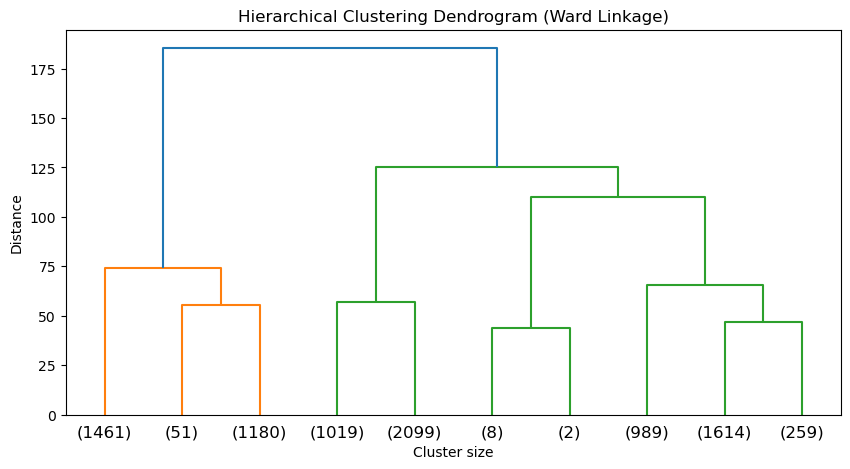

In [15]:
Z = linkage(X_scaled, method='ward')
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=10)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()


6. AGGLOMERATIVE CLUSTERING 

In [16]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

df['Facies_HC'] = hc.fit_predict(X_scaled)


7. DEPTH VISUALIZATION

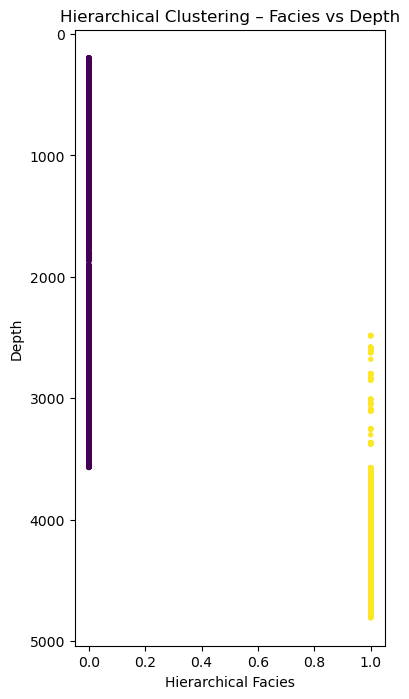

In [17]:
plt.figure(figsize=(4, 8))
plt.scatter(df['Facies_HC'], df['Depth'],
            c=df['Facies_HC'], cmap='viridis', s=8)
plt.gca().invert_yaxis()
plt.xlabel("Hierarchical Facies")
plt.ylabel("Depth")
plt.title("Hierarchical Clustering – Facies vs Depth")
plt.show()


In [18]:
df.groupby('Facies_HC')[['Depth','GR', 'RILD', 'RHOB', 'DPOR', 'SP']].mean()

 #   0: Sandstone
 #  1: Shale



,Depth,GR,RILD,RHOB,DPOR,SP
Facies_HC,,,,,,
0,1841.799833,80.587281,29.569132,1.803981,52.983581,-97.258220
1,4074.883915,69.762285,37.028493,2.544939,9.652765,-87.223799


8. SAVING MODEL

In [19]:
folder_path = os.path.abspath("saved_models")
os.makedirs(folder_path, exist_ok=True)

hc_path = os.path.join(folder_path, "hierarchical.pkl")
scaler_path = os.path.join(folder_path, "hc_scaler.pkl")

joblib.dump(hc, hc_path)
joblib.dump(scaler, scaler_path)

print("Hierarchical clustering model saved.")


Hierarchical clustering model saved.


In [20]:
df['Model'] = 'Hierarchical'
df['sand_score'] = None
df['Facies'] = df['Facies_HC']

df.to_csv('hierarchical_output.csv', index=False)
